# Comparison of edge detectors

In [1]:
#Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

## Gradient method:

### (a) I/O function:

In [2]:
def io_image(f_name):
    """
    Read an image file and convert it to a numpy array.
    Input: f_name -> path to the image file.
    Output: im_arr -> numpy array representation of the image.
    """
    # Call the PIL reader
    img = Image.open(f_name)
    # Convert to an array
    im_arr = np.array(img)
    
    return im_arr

In [3]:
# Test call

# File path
f_img1 = "/home/prostofsound/jnotebooks/computational-physics-1/Notes/data/clouds.jpg"

# Call our I/O function
im_bw = io_image(f_img1)

# Check the shape of the image
print(im_bw.shape)

(311, 453, 3)


### (b) Image inspection:

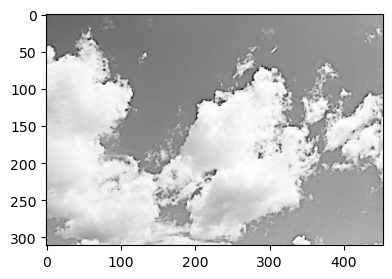

In [4]:
# Image B/W
plt.figure(figsize=(5, 3))

plt.imshow(im_bw[:, :, 0], cmap='Greys_r') #select just one channel

plt.show()

In [5]:
# Pixel intensity
print(f" min. pixel intensity: {np.min(im_bw[:, :, 0])}")
print(f" max. pixel intensity: {np.max(im_bw[:, :, 0])}")

 min. pixel intensity: 0
 max. pixel intensity: 255


### (c) Edge detector 1: Derivatives

In [6]:
def edge_diff(im_channel):
    """
    Edge detector function that uses intensity gradient maps.
    Input: im_channel -> 1 channel.
    Output: grad_mag-> gradient magnitude.
    """
    #Gradient
    grad_ch = np.gradient(im_channel) #spacing is not necessary since we are using pixel spacing

    # Calculate the gradient magnitude
    grad_mag = np.sqrt(grad_ch[0]**2 + grad_ch[1]**2)
    
    #Isolate large gradients
    grad_mag_2 = np.where(grad_mag > 15, 1 , 0)
    
    return grad_mag_2

In [7]:
#Call our edge detector 1
map_1 = edge_diff(im_bw[:, :, 0])

#Safe check
print(map_1.shape, np.max(map_1), np.min(map_1))

(311, 453) 1 0


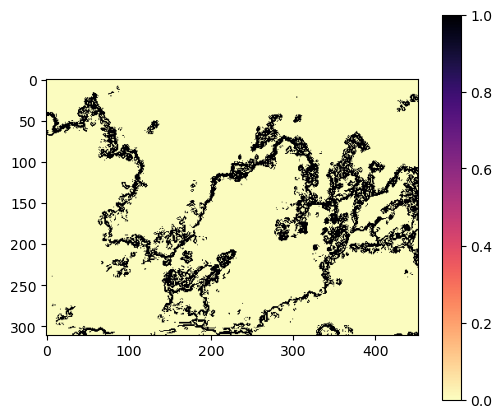

In [8]:
#Plotting
plt.figure(figsize=(6, 5))

plt.imshow(map_1, cmap='magma_r')

plt.colorbar()

plt.show()

## FFT Method:

### Mask (High pass):

In [9]:
# Offset from the centre
r_off = 10

im1 = Image.new(mode="RGB", size=(im_bw[:,:,0].shape[1], im_bw[:,:,0].shape[0]))
draw = ImageDraw.Draw(im1)
draw.ellipse((im_bw[:,:,0].shape[1]//2 - r_off, im_bw[:,:,0].shape[0]//2 - r_off,\
              im_bw[:,:,0].shape[1]//2 + r_off, im_bw[:,:,0].shape[0]//2 + r_off), fill=(255, 0, 0), outline=(0, 0, 0))

# Binary image
mask_1 = np.array(im1)[:,:,0]//255

mask_2 = - mask_1 + 1

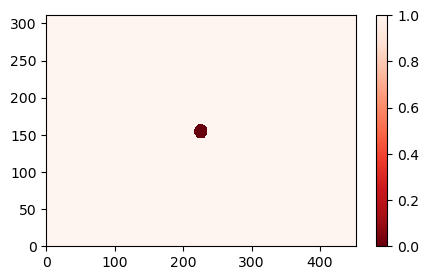

In [10]:
# Plotting
plt.figure(figsize=(5,3))

z = plt.pcolor(mask_2, cmap = "Reds_r")

plt.colorbar(z)

plt.show()

### (d) Edge detector 2 : FFT

In [11]:
def edge_fft(im_channel):
    """
    Edge detector function that uses FFT.
    Input: im_channel -> 1 channel.
    Output: fft_map-> binary map.
    """
    # FFT of the image
    fft_ch = np.fft.fft2(im_channel)

    # Shift low frequencies to the center
    fft_sh = np.fft.fftshift(fft_ch)

    # Calculate the magnitude, to get just the real values
    mag = np.abs(fft_sh)
    
    # Construct the mask

    mask_1 = Image.new(mode="RGB", size=(im_channel.shape[1], im_channel.shape[0]))

    draw = ImageDraw.Draw(mask_1)

    # Offset from the centre
    r_off = 10

    # Use pillow to draw a circle
    draw.ellipse((im_channel.shape[1]//2 - r_off, im_channel.shape[0]//2 - r_off,\
                  im_channel.shape[1]//2 + r_off, im_channel.shape[0]//2 + r_off),\
                  fill=(255, 0, 0), outline=(0, 0, 0))
    # Binary image
    mask = np.array(mask_1)[:, :, 0]//255
    # Invert the mask, to get the high frequencies
    mask = - mask + 1

    # Apply the mask to the FFT
    im_fft = mask * fft_sh

    # Go back to real space
    # First, unshift back the frequencies
    inv_fft = np.fft.ifftshift(im_fft)

    # Then, carry out the IFFT
    masked_img = np.fft.ifft2(inv_fft)

    #Binary image
    mk_map = np.where(np.abs(masked_img.real) > 22 , 1, 0)

    return mk_map

We've first tried each part of the function separately. Only then, we're sure our code is working. Procedural programming.

In [12]:
#Call our edge detector 2
map_3 = edge_fft(im_bw[:, :, 0])

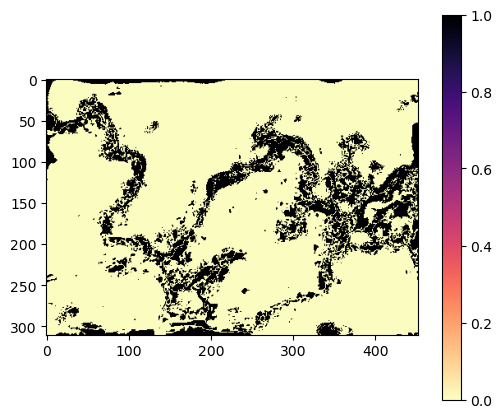

In [13]:
#Plotting

plt.figure(figsize=(6, 5))

z = plt.imshow(map_3, cmap='magma_r')

plt.colorbar(z)

plt.show()

Let's try another image, the Rubik's cube.

In [14]:
# File path
f_img2 = "/home/prostofsound/jnotebooks/computational-physics-1/Notes/data/Rubiks_cube.jpg"

# Call our I/O function
rc = io_image(f_img2)

#Safe check
print(rc.shape)

(1600, 1600, 3)


In [15]:
#Call our edge detector 2
map_4 = edge_fft(rc[:,:, 0])

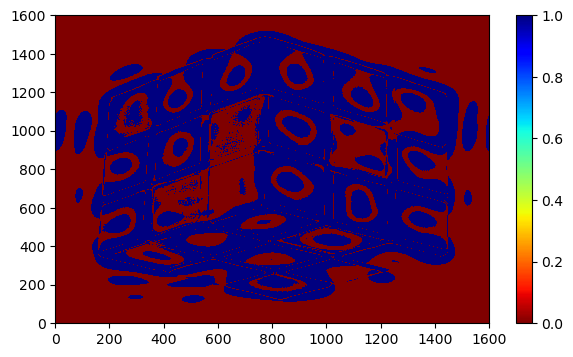

In [16]:
#Plotting

plt.figure(figsize=(7, 4))
z = plt.pcolor(map_4, cmap='jet_r')
plt.colorbar(z)

plt.show()

## Methods comparison:

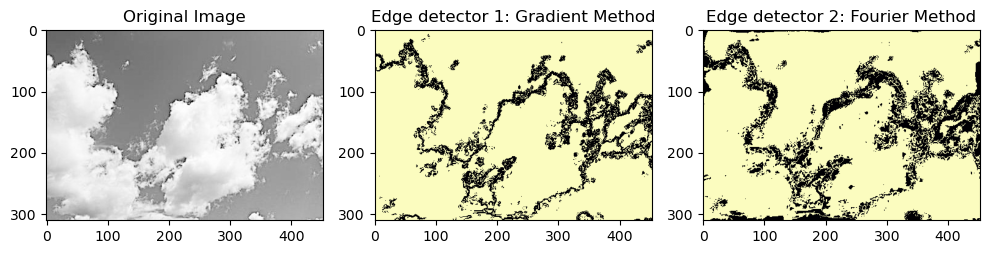

In [18]:
# Create the figure and subplots
fig, ax = plt.subplots(1, 3, figsize=(10, 7)) # 1 row, 3=2 columns

ax[0].imshow(im_bw[:,:,0],  cmap = "Greys_r")
ax[0].set_title("Original Image")

ax[1].imshow(map_1,  cmap = "magma_r", clim = (0, 1))
ax[1].set_title("Edge detector 1: Gradient Method")

ax[2].imshow(map_3,  cmap = "magma_r", clim = (0, 1))
ax[2].set_title("Edge detector 2: Fourier Method")

plt.tight_layout()
plt.show()